In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 

In [ ]:
#df_wildfire_scaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/notebooks/wildfire_scaled.csv')
df_wildfire_scaled = pd.read_csv(/Users/veron/Desktop/natural disasters project/notebooks/wildfire_scaled.csv)
df_wildfire_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_wildfire.csv')

In [3]:
df_wildfire_scaled.head()

,Unnamed: 0,Dis Mag Value,Total Deaths,Total Affected,duration_days,Fatality Rate
0,0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0


In [4]:
wildfire_features = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'duration_days']
X = df_wildfire_scaled[wildfire_features]
X.isna().sum()

Dis Mag Value     0
Total Deaths      0
Total Affected    0
Fatality Rate     0
duration_days     0
dtype: int64

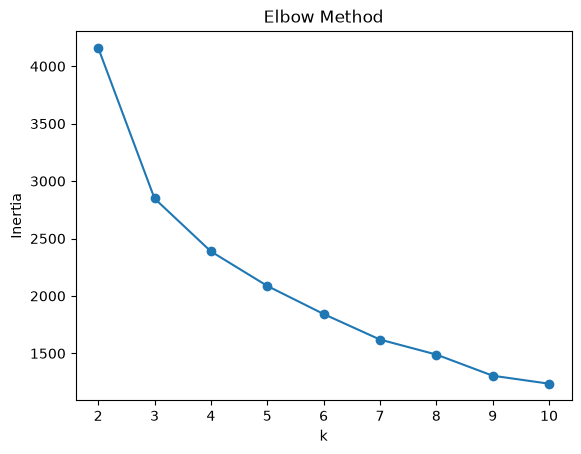

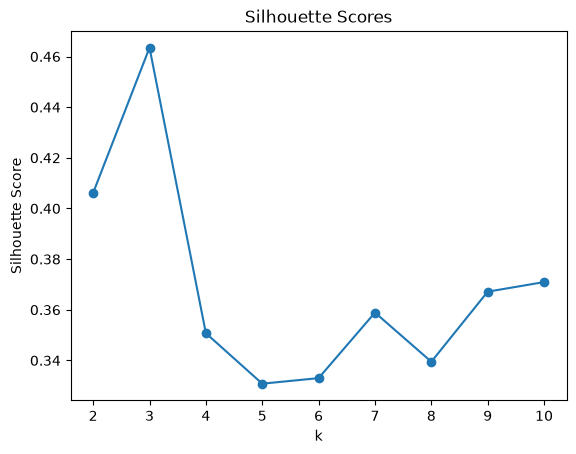

In [5]:
wildfire_features = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'duration_days']
X = df_wildfire_scaled[wildfire_features]

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Elbow plot
plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette plot
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

### First try k = 2.

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_wildfire_scaled['cluster'] = kmeans.fit_predict(df_wildfire_scaled[wildfire_features])

df_wildfire_scaled.groupby('cluster')[wildfire_features].mean()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,duration_days
cluster,,,,,
0,0.038072,0.126821,0.826849,0.000241,0.514373
1,-0.155104,0.067523,-3.815948,2.275215,0.647372


### Now k = 3.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_wildfire_scaled['cluster'] = kmeans.fit_predict(df_wildfire_scaled[wildfire_features])

df_wildfire_scaled.groupby('cluster')[wildfire_features].mean()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,duration_days
cluster,,,,,
0,-0.138423,0.023420,-0.390129,0.174002,0.452740
1,0.746504,0.525218,4.513271,-0.248224,0.882110
2,0.010239,0.310254,-6.000684,4.981895,0.785098


In [8]:
df_wildfire_unscaled['cluster'] = df_wildfire_scaled['cluster']

df_wildfire_unscaled['Fatality Rate'] = (df_wildfire_unscaled['Total Deaths'] / df_wildfire_unscaled['Total Affected']).clip(upper=1.0)
df_wildfire_unscaled.groupby('cluster')[['Dis Mag Value', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'duration_days']].median()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,duration_days
cluster,,,,,
0,247.5,4.0,603.0,0.004975,0.0
1,2055.0,11.0,14018.0,0.000833,3.5
2,607.0,7.0,13.5,0.666667,2.0


### Note:
- Dis Mag Value shows extreme right-skew (std >> mean), driven by a small number of catastrophic wildfires; raw cluster means are outlier-distorted, so log-transformed (scaled) rankings and/or raw medians are used for interpretation instead.

In [9]:
df_wildfire_unscaled.describe()

,Dis Mag Value,Total Deaths,Total Affected,duration_days,CPI,Year,cluster,Fatality Rate
count,183.000000,181.000000,2.530000e+02,281.000000,436.000000,436.000000,436.000000,133.000000
mean,6539.622951,15.690608,6.827258e+04,10.911032,67.055534,2000.224771,0.270642,0.078632
std,51051.997020,29.959109,6.596322e+05,27.483552,20.944548,12.128998,0.563373,0.229481
min,1.000000,1.000000,1.000000e+00,0.000000,15.001282,1970.000000,0.000000,0.000001
25%,80.500000,2.000000,2.000000e+02,0.000000,57.271483,1994.000000,0.000000,0.001333
50%,349.000000,5.000000,1.000000e+03,0.000000,66.534994,2000.000000,0.000000,0.004444
75%,1340.000000,15.000000,4.508000e+03,7.000000,83.189023,2009.000000,0.000000,0.019608
max,680000.000000,240.000000,1.000220e+07,213.000000,100.000000,2020.000000,2.000000,1.000000


### Clusters and interpretations (scaled):
- Cluster 0: lowest spread, moderate fatality, lowest duration (low vigour surface fire, rank 2)
- Cluster 1: greatest spread, lowest fatality, longest duration (smouldering ground fire, rank 1)
- Cluster 2: moderate spread, extreme fatality, moderate duration (moderately vigorous surface fire, rank 3)

### Clusters and interpretations (unscaled):
- Cluster 0: lowest spread, moderate fatalitxy, lowest duration
- Cluster 1: greatest spread, lowest fatality, longest duration
- Cluster 2: moderate spread, extreme fatality, moderate duration

#### Note: 
- Difficult to interpret each cluster doesn't move in the same direction - i.e, one cluster could have greater spread yet lower fatality. 

In [10]:
df_wildfire_scaled['cluster'].value_counts()

cluster
0    344
1     66
2     26
Name: count, dtype: int64

In [11]:
df_wildfire_unscaled['Total Affected'].describe()

count    2.530000e+02
mean     6.827258e+04
std      6.596322e+05
min      1.000000e+00
25%      2.000000e+02
50%      1.000000e+03
75%      4.508000e+03
max      1.000220e+07
Name: Total Affected, dtype: float64